In [3]:
import networkx as nx
import numpy as np

N = 1000
k = 10
trials = 5

p_er = k / (N - 1)

print("Number of nodes (N):", N)
print("Target average degree (k):", k)
print("ER Probability (p):", p_er)
print("--------------------------------------------------")

clustering_vals = []
path_lengths = []
diameters = []

for _ in range(trials):
    G = nx.erdos_renyi_graph(N, p_er)

    if not nx.is_connected(G):
        largest_component = max(nx.connected_components(G), key=len)
        G = G.subgraph(largest_component).copy()

    clustering_vals.append(nx.average_clustering(G))
    path_lengths.append(nx.average_shortest_path_length(G))
    diameters.append(nx.diameter(G))

print("Results (Averaged over", trials, "trials)")
print("Average Clustering Coefficient :", np.mean(clustering_vals))
print("Average Shortest Path Length   :", np.mean(path_lengths))
print("Average Diameter               :", np.mean(diameters))


Number of nodes (N): 1000
Target average degree (k): 10
ER Probability (p): 0.01001001001001001
--------------------------------------------------
Results (Averaged over 5 trials)
Average Clustering Coefficient : 0.010713547198572506
Average Shortest Path Length   : 3.246385985985986
Average Diameter               : 5.0


Erdős–Rényi Results
Clustering Coefficient: 0.009054947489133115
Average Shortest Path: 3.251963963963964


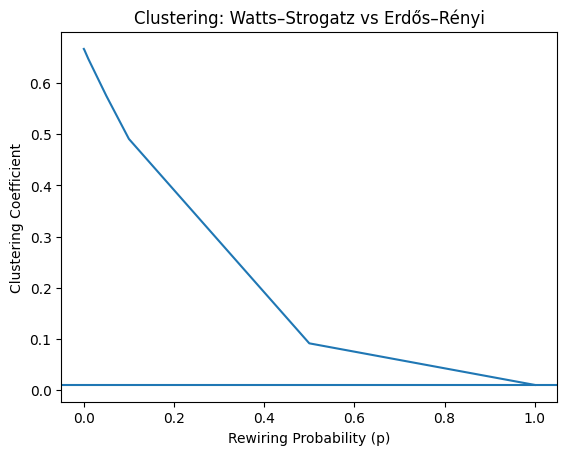

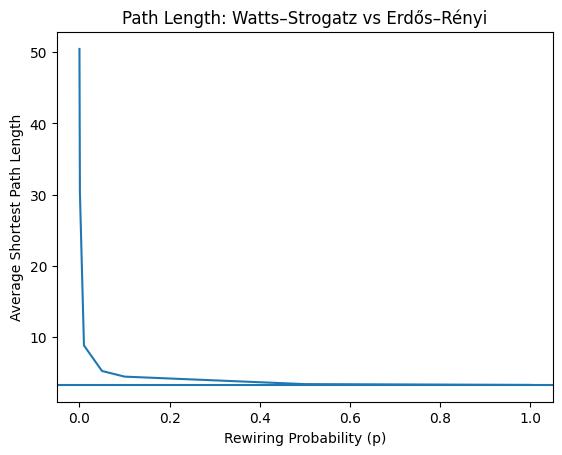

In [4]:

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt


N = 1000
k = 10
p_values = [0, 0.001, 0.01, 0.05, 0.1, 0.5, 1]
trials = 5


ws_clustering = []
ws_path = []

for p in p_values:
    clustering_trials = []
    path_trials = []
    
    for _ in range(trials):
        G_ws = nx.watts_strogatz_graph(N, k, p)
        if not nx.is_connected(G_ws):
            G_ws = G_ws.subgraph(max(nx.connected_components(G_ws), key=len)).copy()
        
        clustering_trials.append(nx.average_clustering(G_ws))
        path_trials.append(nx.average_shortest_path_length(G_ws))
    
    ws_clustering.append(np.mean(clustering_trials))
    ws_path.append(np.mean(path_trials))


p_er = k / (N - 1)

er_clustering_trials = []
er_path_trials = []

for _ in range(trials):
    G_er = nx.erdos_renyi_graph(N, p_er)
    if not nx.is_connected(G_er):
        G_er = G_er.subgraph(max(nx.connected_components(G_er), key=len)).copy()
    
    er_clustering_trials.append(nx.average_clustering(G_er))
    er_path_trials.append(nx.average_shortest_path_length(G_er))

er_clustering = np.mean(er_clustering_trials)
er_path = np.mean(er_path_trials)

print("Erdős–Rényi Results")
print("Clustering Coefficient:", er_clustering)
print("Average Shortest Path:", er_path)


plt.figure()
plt.plot(p_values, ws_clustering)
plt.axhline(y=er_clustering)
plt.xlabel("Rewiring Probability (p)")
plt.ylabel("Clustering Coefficient")
plt.title("Clustering: Watts–Strogatz vs Erdős–Rényi")
plt.show()


plt.figure()
plt.plot(p_values, ws_path)
plt.axhline(y=er_path)
plt.xlabel("Rewiring Probability (p)")
plt.ylabel("Average Shortest Path Length")
plt.title("Path Length: Watts–Strogatz vs Erdős–Rényi")
plt.show()


n = 5000
Target average degree = 8
Probability p = 0.0016003200640128026
--------------------------------------------------
Mean degree: 7.9576
Variance of degree: 7.944202239999998
Clustering coefficient: 0.0016922522575463748


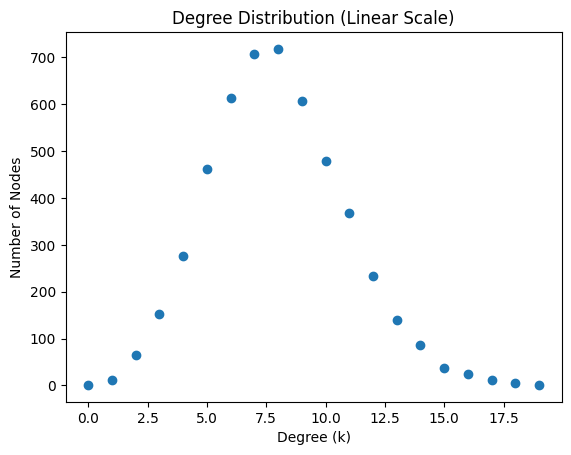

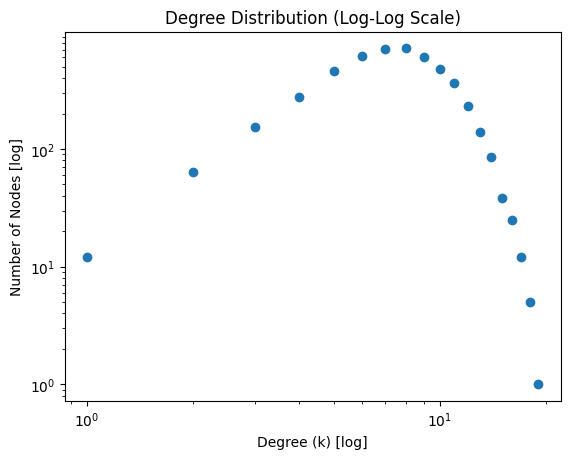

In [7]:
#Q2

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

n = 5000
k_avg = 8
p = k_avg / (n - 1)

print("n =", n)
print("Target average degree =", k_avg)
print("Probability p =", p)
print("--------------------------------------------------")

G = nx.erdos_renyi_graph(n, p)

degrees = [deg for node, deg in G.degree()]


degree_count = Counter(degrees)
deg, count = zip(*sorted(degree_count.items()))

mean_degree = np.mean(degrees)
var_degree = np.var(degrees)

clustering = nx.average_clustering(G)

print("Mean degree:", mean_degree)
print("Variance of degree:", var_degree)
print("Clustering coefficient:", clustering)


plt.figure()
plt.scatter(deg, count)
plt.xlabel("Degree (k)")
plt.ylabel("Number of Nodes")
plt.title("Degree Distribution (Linear Scale)")
plt.show()



plt.figure()
plt.scatter(deg, count)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree (k) [log]")
plt.ylabel("Number of Nodes [log]")
plt.title("Degree Distribution (Log-Log Scale)")
plt.show()
